       Age  Gender  Weight  Height   BMI  Smoking Physical_Activity  \
0       48    Male      78     157  26.4    Never         Sedentary   
1       35  Female      73     163  33.0    Never            Active   
2       79  Female      88     152  32.3    Never          Moderate   
3       75    Male     106     171  37.4    Never          Moderate   
4       34  Female      65     191  18.5  Current         Sedentary   
...    ...     ...     ...     ...   ...      ...               ...   
49995   74    Male     104     155  29.9  Current            Active   
49996   53    Male      95     163  35.8    Never          Moderate   
49997   38  Female      91     197  32.3   Former          Moderate   
49998   68    Male     115     152  18.6    Never          Moderate   
49999   53  Female      81     193  21.7    Never          Moderate   

            Diet Stress_Level  Hypertension  Diabetes  Hyperlipidemia  \
0        Healthy       Medium             0         0               1   
1

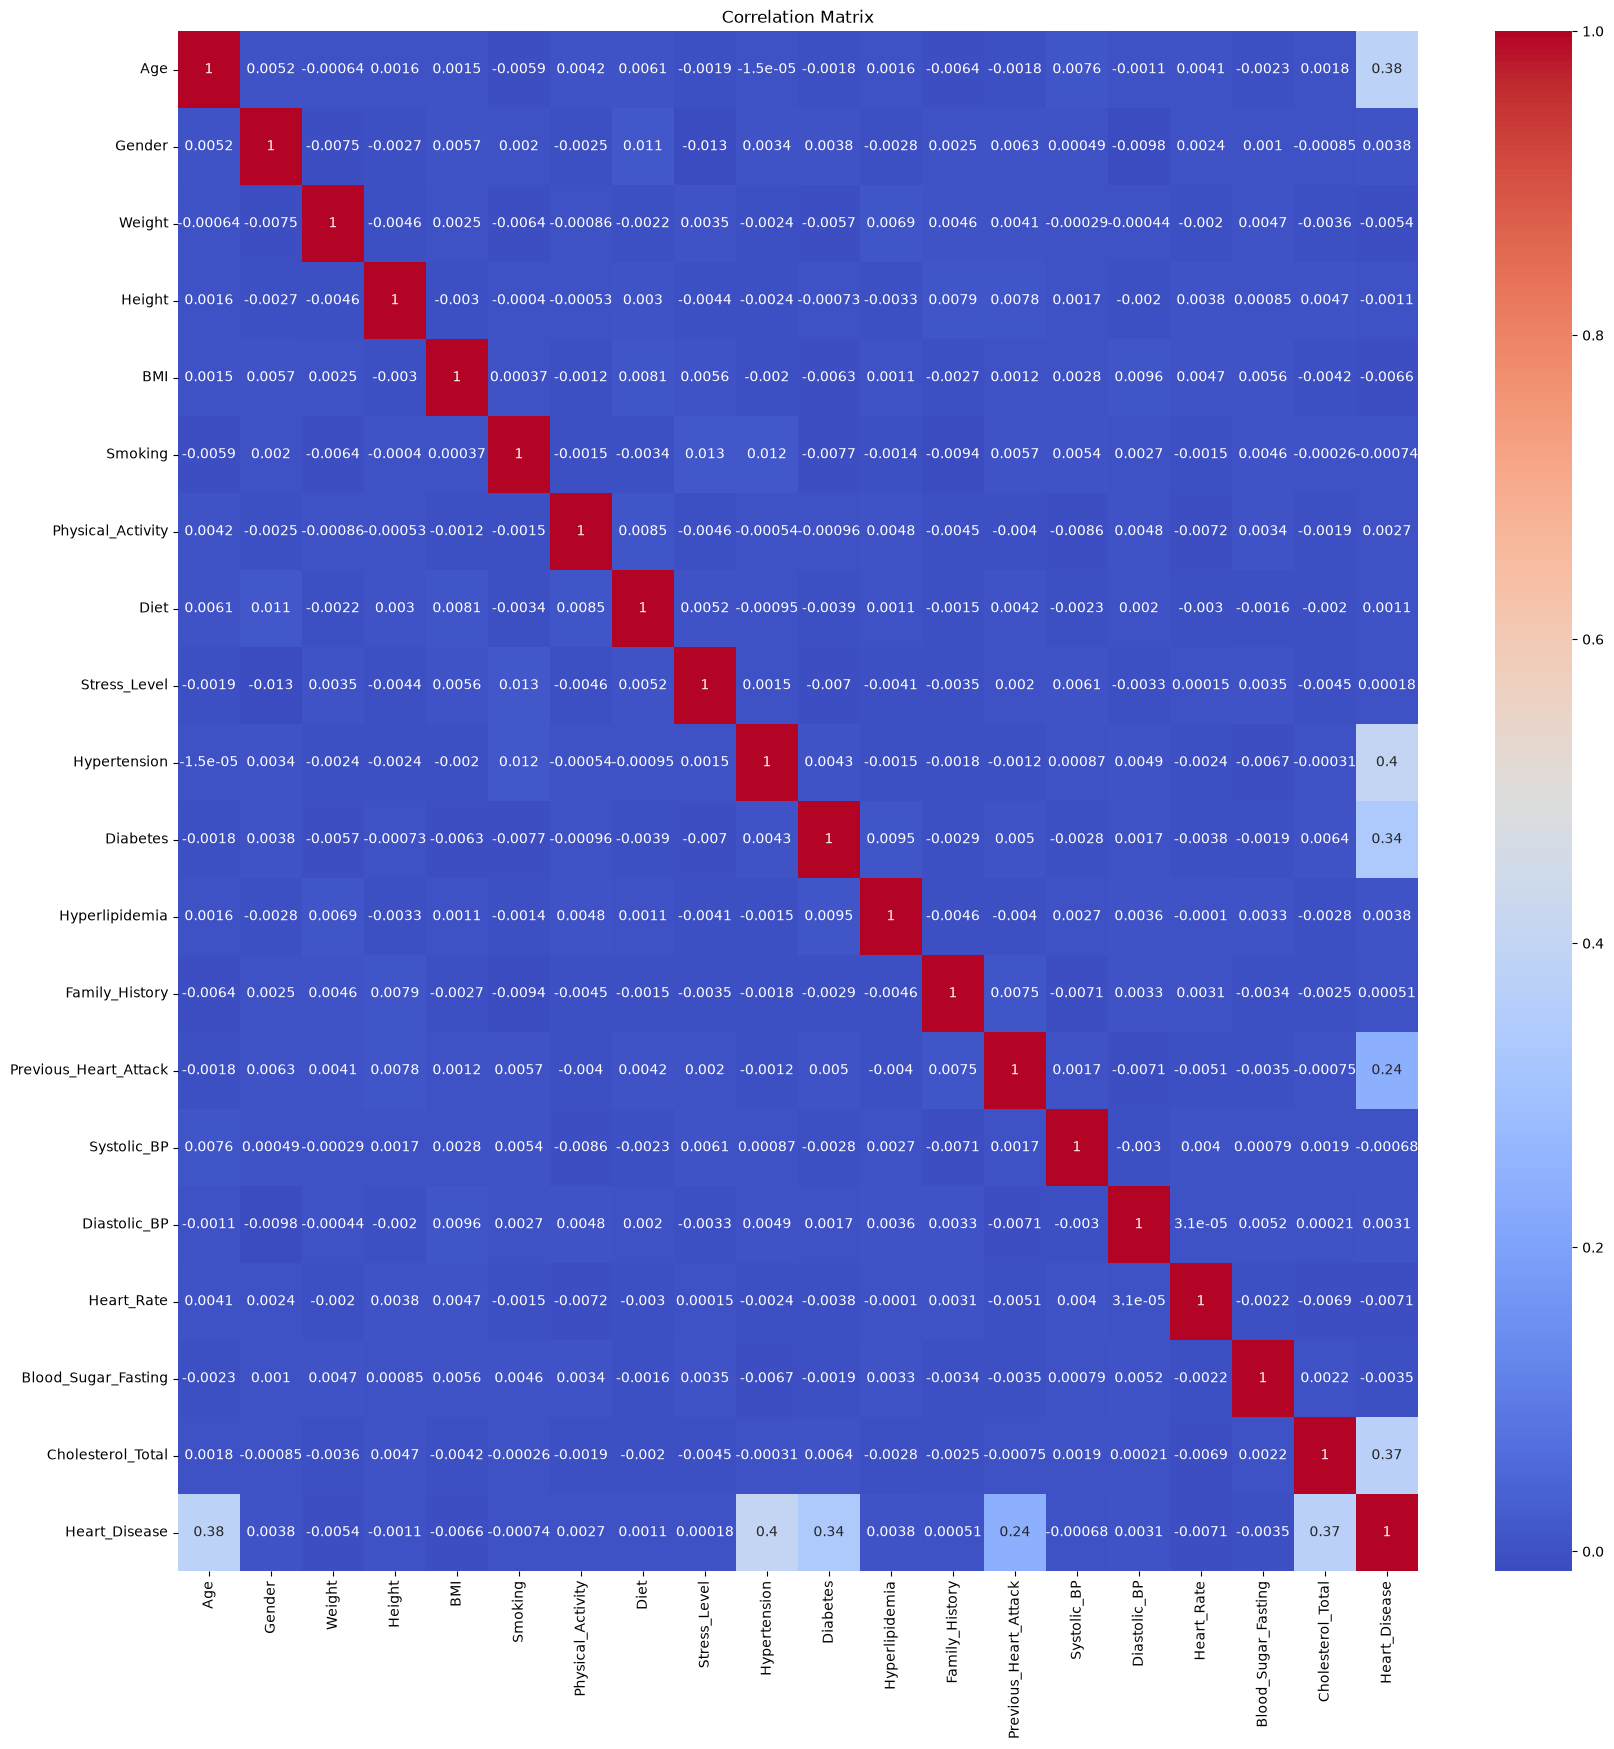

In [1]:
import pandas as pd
import numpy as np
data=pd.read_csv("my_dataset.csv")
data.drop("Alcohol_Intake",axis=1, inplace=True)
print(data)
print(data.info())
data.isna().sum()
list1=['Gender','Smoking','Physical_Activity', 'Diet','Stress_Level']
data[list1]=data[list1].replace({'Male':1,'Female':0,'Never':0,'Current':1,'Former':3,'NaN':0,'Moderate':1,'Low':2,'Sedentary':0,'Active':1,'Healthy':0,'Average':1,'Unhealthy':2,'Medium':0,'High':1})
data.info()
core=data.corr()
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,20))
sns.heatmap(core,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

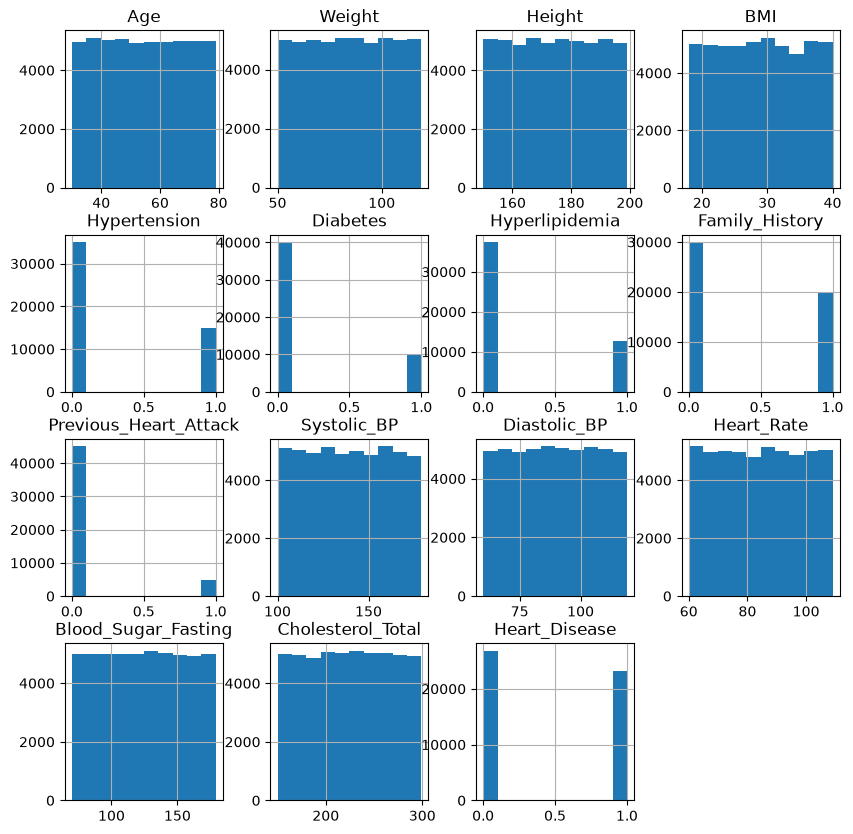

In [2]:
data.hist(figsize=(10,10), bins=10)
plt.show()


In [3]:
from sklearn.model_selection import train_test_split
X = data.drop("Heart_Disease",axis=1)
y = data["Heart_Disease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd


def find_best_model(X, y):

    models = {
        'Logistic Regression': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))
            ]),
            'params': {
                'clf__C': [1, 5, 10]
            }
        },

        'Decision Tree': {
            'model': DecisionTreeClassifier(random_state=42),
            'params': {
                'criterion': ['gini', 'entropy'],
                'max_depth': [5, 10, None]
            }
        },

        'Random Forest': {
            'model': RandomForestClassifier(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, None]
            }
        },

        'SVM': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('clf', SVC(random_state=42))
            ]),
            'params': {
                'clf__C': [1, 10, 20],
                'clf__kernel': ['linear', 'rbf']
            }
        }
    }

    scores = []

    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

    for name, mp in models.items():

        grid = GridSearchCV(
            estimator=mp['model'],
            param_grid=mp['params'],
            cv=cv,
            n_jobs=-1,
            scoring='accuracy'
        )

        grid.fit(X, y)

        scores.append({
            "Model": name,
            "Best Score": grid.best_score_,
            "Best Params": grid.best_params_
        })

    return pd.DataFrame(scores)

In [ ]:
result_df = find_best_model(X_train, y_train)
result_df

In [ ]:
import joblib
from sklearn.ensemble import RandomForestClassifier

# Train your model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Save the model
joblib.dump(model, "heart_disease_rf.pkl")

print("Model saved successfully!")

In [ ]:
import joblib

# Load the model
model = joblib.load("heart_disease_rf.pkl")

print("Model loaded successfully!")